In [220]:
# Importing esential libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


In [166]:
# Mounting (Colab only - safe to skip outside Colab)

import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print("Not running in Google Colab (or Drive not available). Skipping drive.mount().")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [167]:
# Dataset loading

cars_data = pd.read_csv("/content/drive/MyDrive/Study /ML/Final Code DTI/Cardetails.csv")
cars_data.head()




,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [168]:
# Droping unnesesary column
cars_data.drop(columns=['torque'], inplace=True)

In [169]:
cars_data.shape

(8128, 12)

##  PREPROCESSING

In [170]:
# null check
cars_data.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [171]:
# Drop all the nulll value
cars_data.dropna(inplace=True)

In [172]:
# Dublicate chack
cars_data.duplicated().sum()

np.int64(1189)

In [173]:
# Drop all the Dublicate value
cars_data.drop_duplicates(inplace=True)

In [174]:
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6718 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6718 non-null   object 
 1   year           6718 non-null   int64  
 2   selling_price  6718 non-null   int64  
 3   km_driven      6718 non-null   int64  
 4   fuel           6718 non-null   object 
 5   seller_type    6718 non-null   object 
 6   transmission   6718 non-null   object 
 7   owner          6718 non-null   object 
 8   mileage        6718 non-null   object 
 9   engine         6718 non-null   object 
 10  max_power      6718 non-null   object 
 11  seats          6718 non-null   float64
dtypes: float64(1), int64(3), object(8)
memory usage: 682.3+ KB


In [175]:
# Data analysis
for col in cars_data.columns:
  print('Unique value of' + col)
  print(cars_data[col].unique)
  print("======================\n")

Unique value ofname
<bound method Series.unique of 0                  Maruti Swift Dzire VDI
1            Skoda Rapid 1.5 TDI Ambition
2                Honda City 2017-2020 EXi
3               Hyundai i20 Sportz Diesel
4                  Maruti Swift VXI BSIII
                      ...                
8121    Maruti Wagon R VXI BS IV with ABS
8122           Hyundai i20 Magna 1.4 CRDi
8123                    Hyundai i20 Magna
8124                Hyundai Verna CRDi SX
8125               Maruti Swift Dzire ZDi
Name: name, Length: 6718, dtype: object>

Unique value ofyear
<bound method Series.unique of 0       2014
1       2014
2       2006
3       2010
4       2007
        ... 
8121    2013
8122    2014
8123    2013
8124    2007
8125    2009
Name: year, Length: 6718, dtype: int64>

Unique value ofselling_price
<bound method Series.unique of 0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8121    260000
8122    475000
8123    320000
8124    135000


In [176]:
# Convert from Brand model name to Brand name
def get_brand_name (car_name):
  car_name = car_name.split(' ') [0]
  return car_name.strip()

In [177]:
# Convert from all Brand model name to Brand name
def clean_data(value):

  if pd.isna(value):
    return np.nan
  value = str(value).strip()
  if value == '':
    return np.nan

  token = value.split(' ')[0].strip().replace(',', '')
  if token == '':
    return np.nan

  return pd.to_numeric(token, errors='coerce')


In [178]:
get_brand_name('Maruti Swift Dzire zDi')

'Maruti'

In [179]:
# Apply Brand model name to Brand name
cars_data['name'] = cars_data['name'].apply(get_brand_name)

In [180]:
cars_data['name'].unique()

array(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Datsun', 'Jeep', 'Mercedes-Benz',
       'Mitsubishi', 'Audi', 'Volkswagen', 'BMW', 'Nissan', 'Lexus',
       'Jaguar', 'Land', 'MG', 'Volvo', 'Daewoo', 'Kia', 'Fiat', 'Force',
       'Ambassador', 'Ashok', 'Isuzu', 'Opel'], dtype=object)

In [181]:
# For mileage
cars_data['mileage'] = cars_data['mileage'].apply(clean_data)

In [182]:
# For max_power
cars_data['max_power'] = cars_data['max_power'].apply(clean_data)

In [183]:
# For enginea
cars_data['engine'] = cars_data['engine'].apply(clean_data)


In [184]:
for col in cars_data.columns:
  print('Unique value of' + col)
  print(cars_data[col].unique)
  print("======================\n")

Unique value ofname
<bound method Series.unique of 0        Maruti
1         Skoda
2         Honda
3       Hyundai
4        Maruti
         ...   
8121     Maruti
8122    Hyundai
8123    Hyundai
8124    Hyundai
8125     Maruti
Name: name, Length: 6718, dtype: object>

Unique value ofyear
<bound method Series.unique of 0       2014
1       2014
2       2006
3       2010
4       2007
        ... 
8121    2013
8122    2014
8123    2013
8124    2007
8125    2009
Name: year, Length: 6718, dtype: int64>

Unique value ofselling_price
<bound method Series.unique of 0       450000
1       370000
2       158000
3       225000
4       130000
         ...  
8121    260000
8122    475000
8123    320000
8124    135000
8125    382000
Name: selling_price, Length: 6718, dtype: int64>

Unique value ofkm_driven
<bound method Series.unique of 0       145500
1       120000
2       140000
3       127000
4       120000
         ...  
8121     50000
8122     80000
8123    110000
8124    119000
8125    120000


In [185]:
# Convert from Categorical to numerical data
cars_data['name'].replace(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Datsun', 'Jeep', 'Mercedes-Benz',
       'Mitsubishi', 'Audi', 'Volkswagen', 'BMW', 'Nissan', 'Lexus',
       'Jaguar', 'Land', 'MG', 'Volvo', 'Daewoo', 'Kia', 'Fiat', 'Force',
       'Ambassador', 'Ashok', 'Isuzu', 'Opel'],
        [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31],
                          inplace=True)

/tmp/ipykernel_1149/1330924603.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars_data['name'].replace(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
/tmp/ipykernel_1149/1330924603.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_data['name'].replace(['Maruti', 'S

In [186]:
# Convert Transmission
cars_data['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [187]:
cars_data['transmission'].replace(['Manual', 'Automatic'], [1,2], inplace=True)

/tmp/ipykernel_1149/3759958917.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars_data['transmission'].replace(['Manual', 'Automatic'], [1,2], inplace=True)
/tmp/ipykernel_1149/3759958917.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_data['transmission'].replace(['Manual', 'Automati

In [188]:
# Convert Seller_type
cars_data['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [189]:
cars_data['seller_type'].replace(['Individual', 'Dealer', 'Trustmark Dealer'], [1,2,3], inplace=True)

/tmp/ipykernel_1149/1715770685.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars_data['seller_type'].replace(['Individual', 'Dealer', 'Trustmark Dealer'], [1,2,3], inplace=True)
/tmp/ipykernel_1149/1715770685.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_data['seller_type'].replace

In [190]:
# Convert fuel
cars_data['fuel'].unique()

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

In [191]:
cars_data['fuel'].replace(['Diesel', 'Petrol', 'LPG', 'CNG'], [1,2,3,4], inplace=True)

/tmp/ipykernel_1149/3462554276.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars_data['fuel'].replace(['Diesel', 'Petrol', 'LPG', 'CNG'], [1,2,3,4], inplace=True)
/tmp/ipykernel_1149/3462554276.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_data['fuel'].replace(['Diesel', 'Petrol', 

In [192]:
# Convert owner
cars_data['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

In [193]:
cars_data['owner'].replace(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], [1,2,3,4,5], inplace=True)

/tmp/ipykernel_1149/1358740473.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars_data['owner'].replace(['First Owner', 'Second Owner', 'Third Owner',
/tmp/ipykernel_1149/1358740473.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_data['owner'].replace(['First Owner', 'Second Owner', '

In [194]:
# Dataset after convert from Categorical to Numerical data

cars_data

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,1,2014,450000,145500,1,1,1,1,23.40,1248,74.00,5.0
1,2,2014,370000,120000,1,1,1,2,21.14,1498,103.52,5.0
2,3,2006,158000,140000,2,1,1,3,17.70,1497,78.00,5.0
3,4,2010,225000,127000,1,1,1,1,23.00,1396,90.00,5.0
4,1,2007,130000,120000,2,1,1,1,16.10,1298,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8121,1,2013,260000,50000,2,1,1,2,18.90,998,67.10,5.0
8122,4,2014,475000,80000,1,1,1,2,22.54,1396,88.73,5.0
8123,4,2013,320000,110000,2,1,1,1,18.50,1197,82.85,5.0
8124,4,2007,135000,119000,1,1,1,4,16.80,1493,110.00,5.0


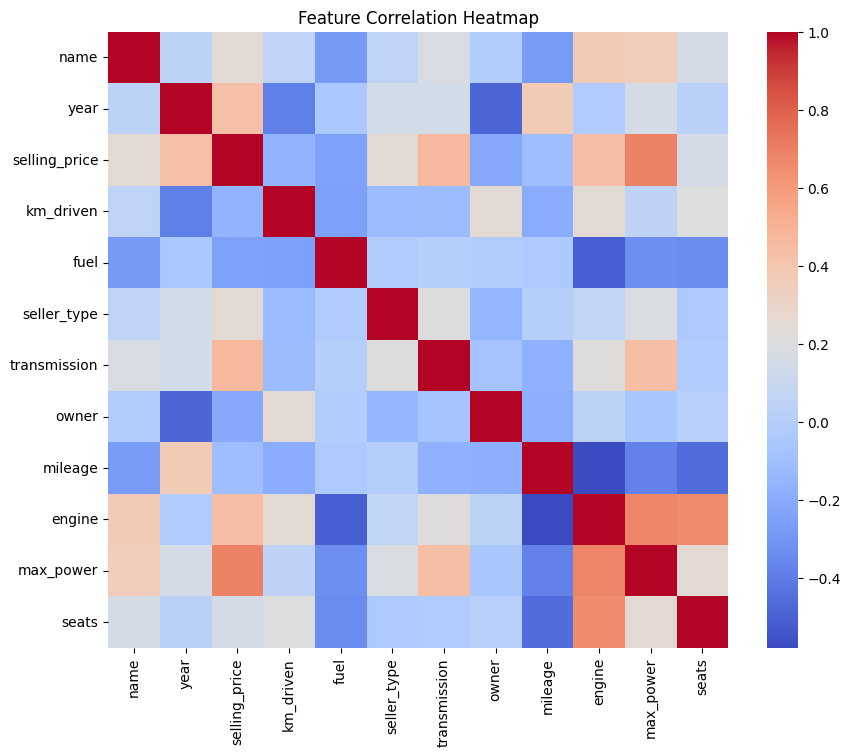

In [195]:
# Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(cars_data.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()


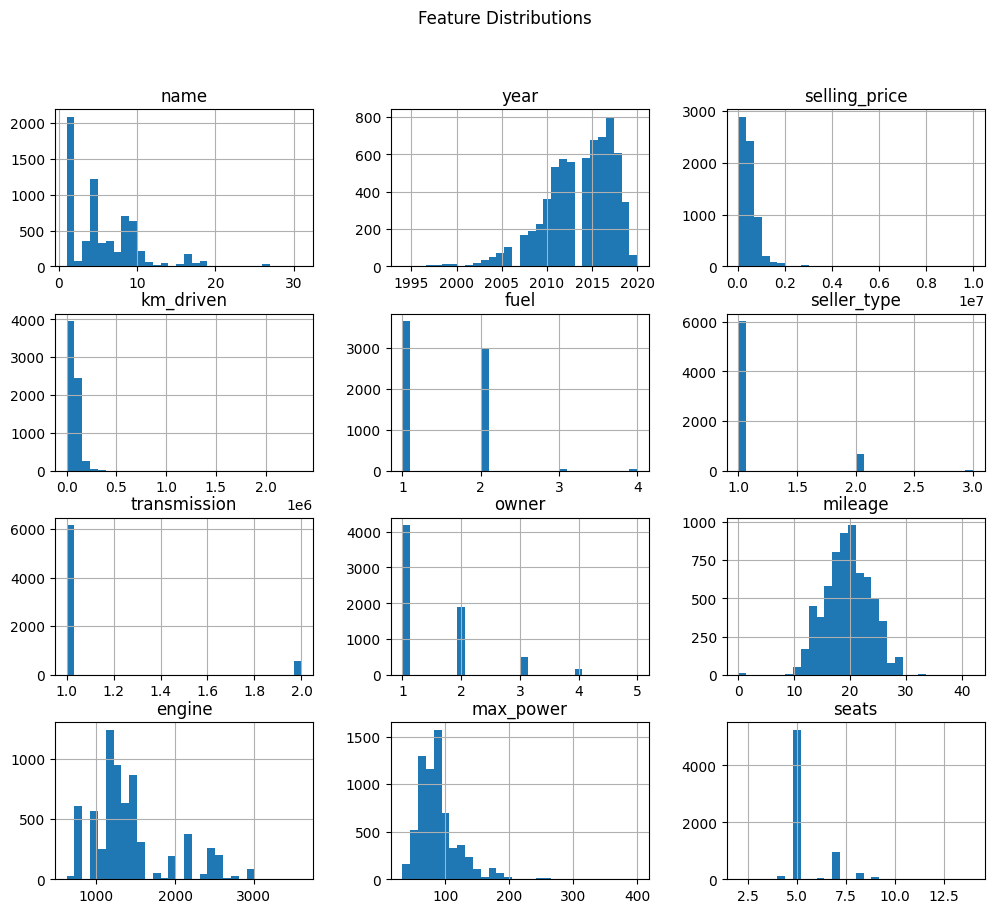

In [196]:
# Feature Distribution (Numerical)

cars_data.hist(figsize=(12,10), bins=30)
plt.suptitle('Feature Distributions')
plt.show()


In [197]:
# Binary target setup
# Compute the FINAL threshold from TRAIN ONLY (to avoid data leakage).
# Here we create a temporary 'price_class' only to keep the same workflow / stratified split style.

y_price = cars_data['selling_price'].copy()

temp_threshold = y_price.median()
cars_data['price_class'] = (y_price >= temp_threshold).astype(int)

print("Temporary threshold (full data median) for initial stratify only:", temp_threshold)
cars_data[['selling_price', 'price_class']].head()


Temporary threshold (full data median) for initial stratify only: 420000.0


,selling_price,price_class
0,450000,1
1,370000,0
2,158000,0
3,225000,0
4,130000,0


In [198]:
# Split input features vs output features

X = cars_data.drop(columns=['selling_price', 'price_class'])
y = cars_data['price_class']

In [199]:

# Train 70%
X_train, X_temp, y_train_tmp, y_temp_tmp, y_train_price, y_temp_price = train_test_split(
    X, y, y_price, test_size=0.30, random_state=42, stratify=y
)

# Compute FINAL threshold from TRAIN ONLY (no leakage)
threshold = y_train_price.median()
print("Final threshold (TRAIN median):", threshold)

# Create final labels using TRAIN threshold
y_train = (y_train_price >= threshold).astype(int)
y_temp  = (y_temp_price  >= threshold).astype(int)

# Validation 20%, Test 10% (stratify using final labels)
X_val, X_test, y_val, y_test, y_val_price, y_test_price = train_test_split(
    X_temp, y_temp, y_temp_price, test_size=1/3, random_state=42, stratify=y_temp
)

# Verification
n = len(cars_data)
print(f"Train: {len(X_train)/n:.2%}")
print(f"Validation: {len(X_val)/n:.2%}")
print(f"Test: {len(X_test)/n:.2%}")

print("Class balance (train/val/test):",
      y_train.mean().round(3),
      y_val.mean().round(3),
      y_test.mean().round(3))


Final threshold (TRAIN median): 420000.0
Train: 69.99%
Validation: 20.01%
Test: 10.00%
Class balance (train/val/test): 0.501 0.501 0.501


In [200]:
# Model Creation

model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])

# Train model
model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000))])

In [201]:
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True))
    ]),
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

### GRAPH SECTION for EACH model

In [202]:
# Training vs Validation Loss Curve

from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

def plot_loss(model, name):
    train_loss, val_loss = [], []

    for i in range(1, 101):
        if 'model__max_iter' in model.get_params():
            model.set_params(model__max_iter=i)

        model.fit(X_train, y_train)
        train_loss.append(log_loss(y_train, model.predict_proba(X_train)))
        val_loss.append(log_loss(y_val, model.predict_proba(X_val)))

    plt.figure(figsize=(7,5))
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title(f'{name} – Training vs Validation Loss')
    plt.xlabel('Iterations')
    plt.ylabel('Log Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


In [203]:
# Confusion Matrix + ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

def plot_confusion_matrix_and_roc(model, name):
    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        try:
            y_prob = model.decision_function(X_test)
        except Exception:
            y_prob = None

    # Confusion Matrix --
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format='d')
    plt.title(f'{name} – Confusion Matrix')
    plt.grid(False)
    plt.show()

    # ROC Curve --
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} – ROC Curve')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
    else:
        print(f"{name}: ROC curve skipped (no probability/decision scores available).")


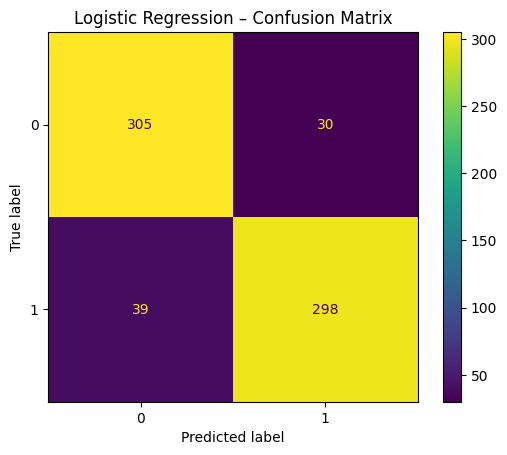

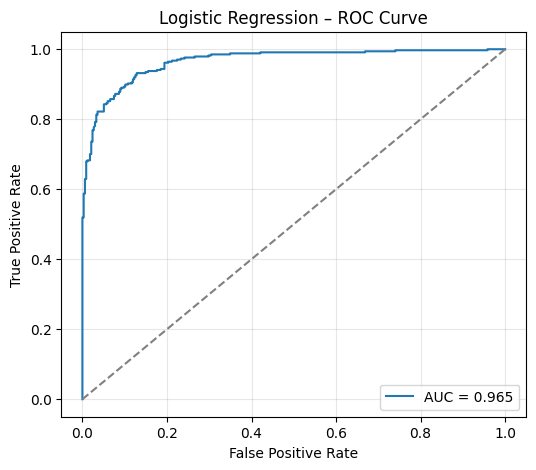

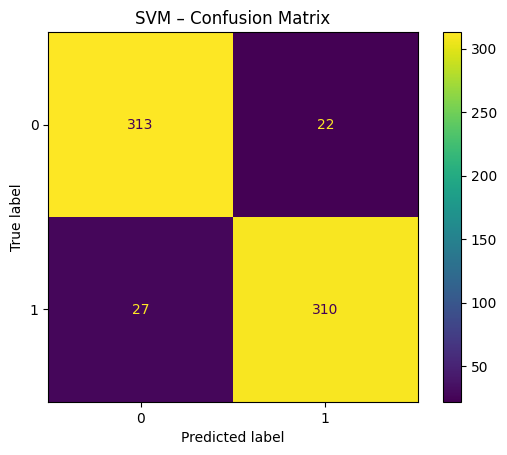

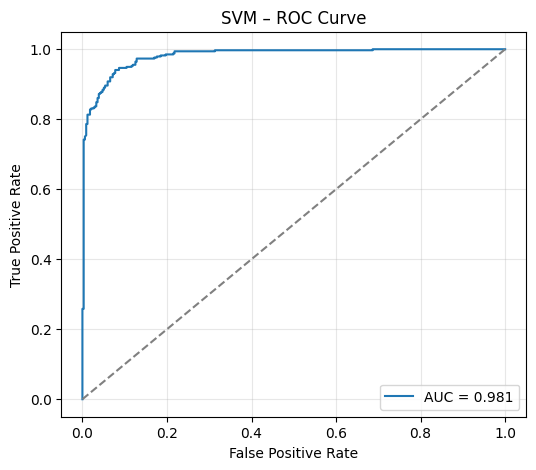

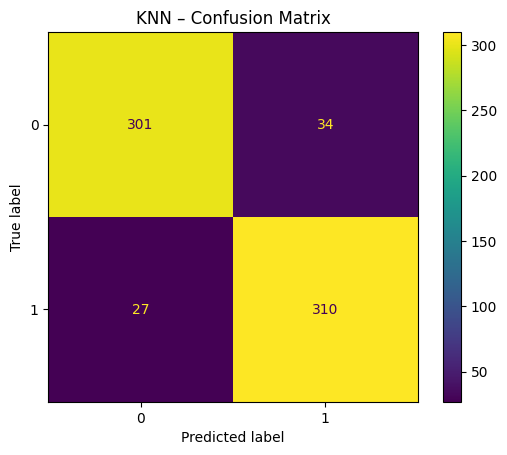

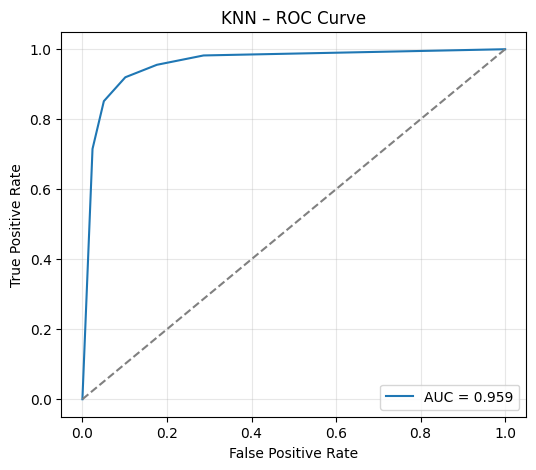

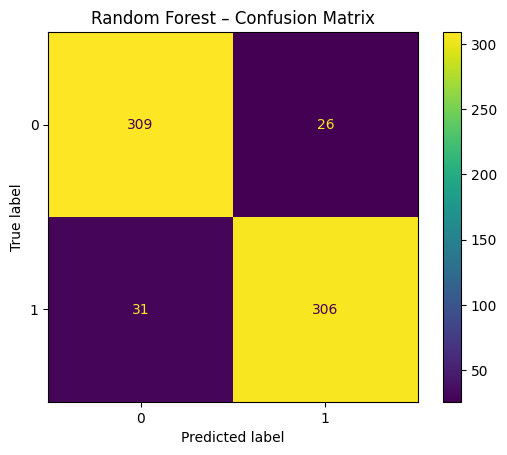

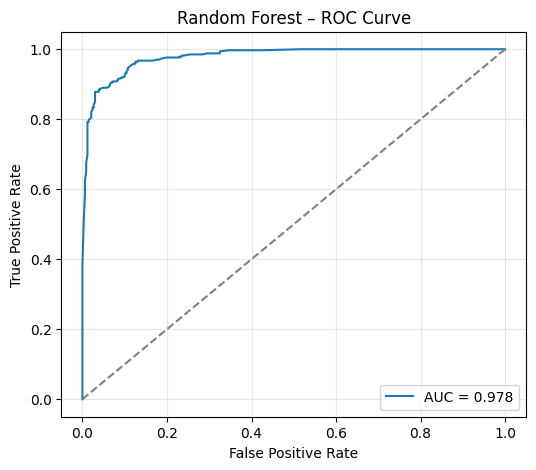

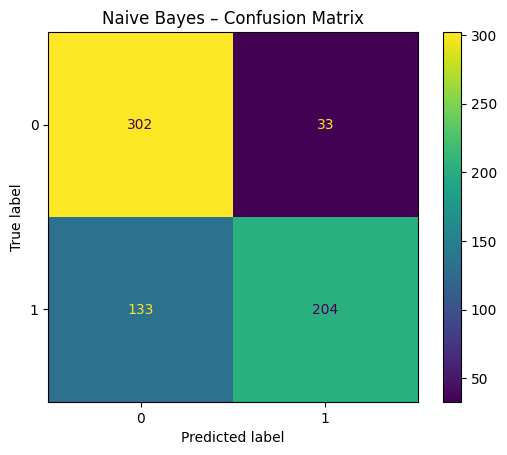

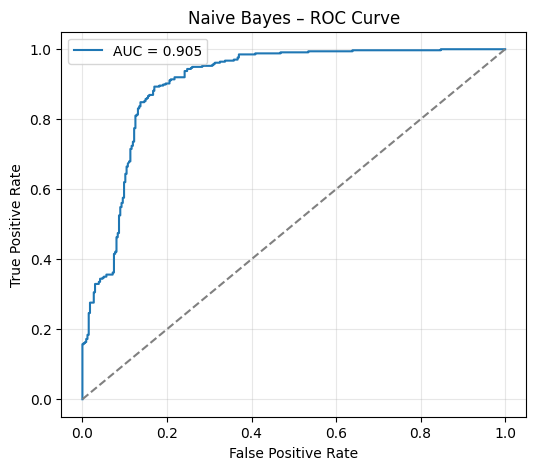

In [204]:
from sklearn.impute import SimpleImputer

# Create a preprocessor that includes imputation and scaling
# All columns are now numerical, so a single pipeline can handle them.
data_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Impute missing values with the median
    ('scaler', StandardScaler()) # Scale features
])

# Update the models to include the preprocessor
fixed_models = {
    "Logistic Regression": Pipeline(steps=[
        ('preprocessor', data_preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=42)) # Added random_state for reproducibility
    ]),
    "SVM": Pipeline(steps=[
        ('preprocessor', data_preprocessor),
        ('model', SVC(probability=True, random_state=42)) # Added random_state for reproducibility
    ]),
    "KNN": Pipeline(steps=[
        ('preprocessor', data_preprocessor),
        ('model', KNeighborsClassifier()) # KNN also benefits from scaling and imputation
    ]),
    "Random Forest": Pipeline(steps=[
        ('preprocessor', data_preprocessor), # Impute and scale before Random Forest
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "Naive Bayes": Pipeline(steps=[
        ('preprocessor', data_preprocessor), # Gaussian Naive Bayes does not handle NaNs, so imputation is necessary
        ('model', GaussianNB())
    ])
}

# Loop through the fixed models and plot their confusion matrix and ROC curve
for name, model in fixed_models.items():
    plot_confusion_matrix_and_roc(model, name)


## MODEL EVALUATION SECTION

In [205]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    mean_squared_error
)
import numpy as np
import pandas as pd

results = {}

for name, model in fixed_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Precision": precision_score(y_test, y_pred),
        "Recall / Sensitivity": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    }

pd.DataFrame(results).T

,Precision,Recall / Sensitivity,F1-score,MSE,RMSE
Logistic Regression,0.908537,0.884273,0.896241,0.102679,0.320435
SVM,0.933735,0.919881,0.926756,0.072917,0.270031
KNN,0.901163,0.919881,0.910426,0.090774,0.301287
Random Forest,0.921687,0.908012,0.914798,0.084821,0.291241
Naive Bayes,0.860759,0.605341,0.710801,0.247024,0.497015


In [206]:
# Accuracy for each model

results = {}

for name, model in fixed_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall / Sensitivity": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    }

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall / Sensitivity,F1-score,MSE,RMSE
Logistic Regression,0.897321,0.908537,0.884273,0.896241,0.102679,0.320435
SVM,0.927083,0.933735,0.919881,0.926756,0.072917,0.270031
KNN,0.909226,0.901163,0.919881,0.910426,0.090774,0.301287
Random Forest,0.915179,0.921687,0.908012,0.914798,0.084821,0.291241
Naive Bayes,0.752976,0.860759,0.605341,0.710801,0.247024,0.497015


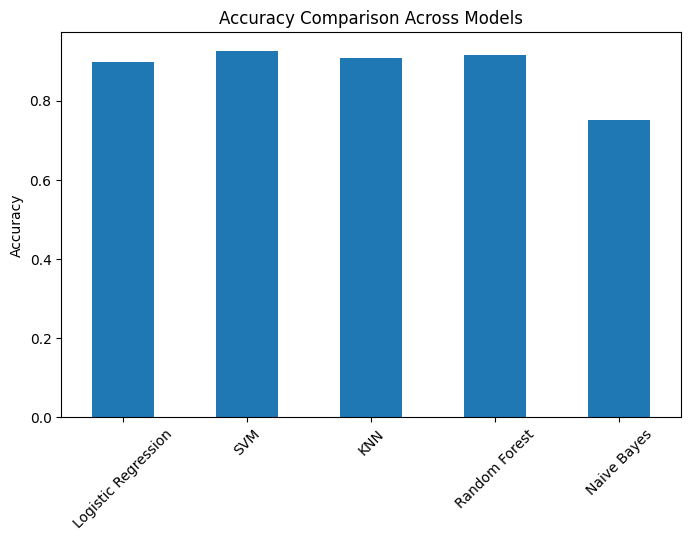

In [207]:
results_df['Accuracy'].plot(kind='bar', figsize=(8,5))
plt.title('Accuracy Comparison Across Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()


## MODEL-LEVEL VISUALIZATIONS (Per Model)

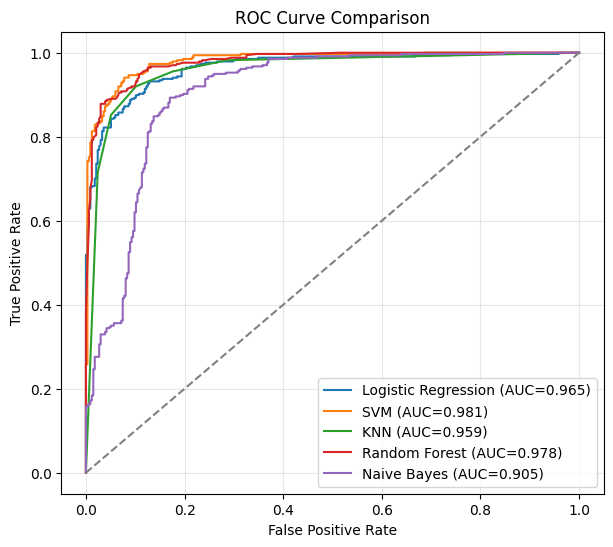

In [208]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

for name, model in fixed_models.items():
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        try:
            y_prob = model.decision_function(X_test)
        except Exception:
            print(f"{name}: skipped in ROC comparison (no scores).")
            continue

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'--', color='gray')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

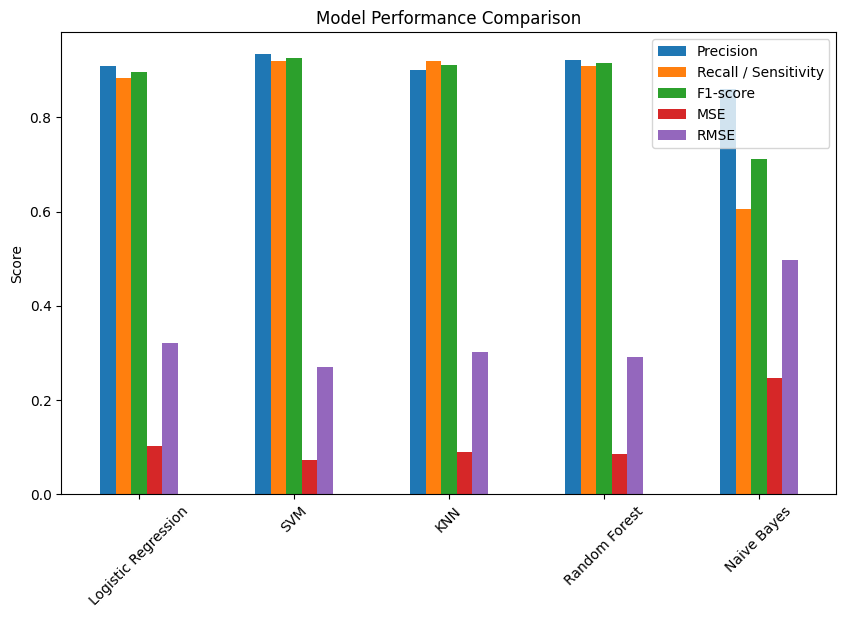

In [209]:
# Model Performance Comparison (Bar Chart)

results_df = pd.DataFrame(results).T

results_df[['Precision','Recall / Sensitivity','F1-score', 'MSE', 'RMSE']].plot(
    kind='bar', figsize=(10,6)
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.show()


## Predict rendom value

In [210]:
model_for_prediction = fixed_models['SVM']
model_for_prediction.fit(X_train, y_train)
y_pred = model_for_prediction.predict(X_test)

In [211]:
y_pred

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,

In [212]:
X_train.head(1)

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
6857,6,2018,50000,1,1,1,4,25.83,1498,99.0,5.0


In [213]:
input_data_model = pd.DataFrame(
    [[8,	2000,	10000,	1,	2,	1,	1,	15.1,	2179.0,	152.87,	5.0]],
    columns = ['name',	'year',	'km_driven', 'fuel',	'seller_type', 'transmission',	'owner',	'mileage',	'engine',	'max_power',	'seats']
)

In [214]:
input_data_model

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,8,2000,10000,1,2,1,1,15.1,2179.0,152.87,5.0


In [215]:
model.predict(input_data_model)

array([0])

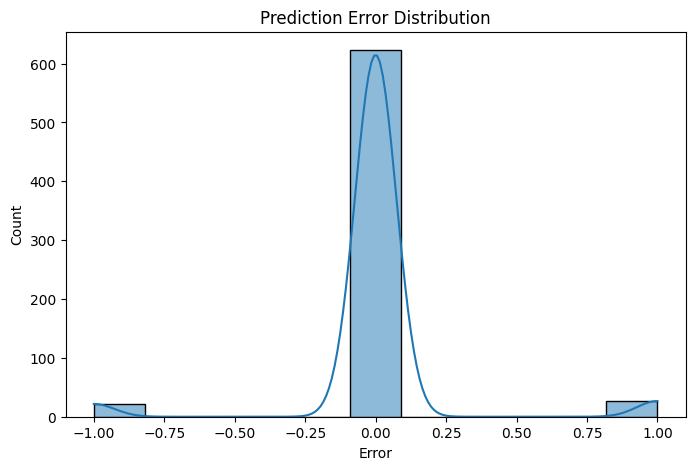

In [216]:
plt.figure(figsize=(8,5))
sns.histplot(y_test - y_pred, kde=True)
plt.title('Prediction Error Distribution')
plt.xlabel('Error')
plt.show()


In [217]:
import pickle as pk

In [218]:
pk.dump(model,open('model.pkl','wb'))

In [219]:
# Best model (based on Test Accuracy)

import pickle as pk

try:
    best_model_name = results_df['Accuracy'].idxmax()
    best_model = models[best_model_name]
    best_model.fit(X_train, y_train)
    pk.dump(best_model, open('best_model.pkl', 'wb'))
    print("Saved best_model.pkl:", best_model_name)
except Exception as e:
    # fallback
    pk.dump(model, open('model.pkl', 'wb'))
    print("Saved model.pkl (baseline). Reason:", e)


Saved best_model.pkl: SVM
